# Setup

Imports

In [1]:
import os
basepath = os.path.expanduser('~')
os.chdir(f"{basepath}/ccvi-data")
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['path.simplify'] = False
import matplotlib.colors as mcolors
from matplotlib.patches import Patch, Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
import matplotlib.text as mtext
import matplotlib.patheffects as path_effects
import numpy as np
import xarray as xr
from panel_imputer import PanelImputer
from base.objects import GlobalBaseGrid, ConfigParser
from utils.conversions import ccvi_series_to_xarray


In [2]:
mpl.rcParams['font.sans-serif']

['DejaVu Sans',
 'Bitstream Vera Sans',
 'Computer Modern Sans Serif',
 'Lucida Grande',
 'Verdana',
 'Geneva',
 'Lucid',
 'Arial',
 'Helvetica',
 'Avant Garde',
 'sans-serif']

Prepare data for analysis. Data corresponds to the scores available for download through our [website](https://climate-conflict.org/data/download/2025-4/ccvi-full-2025-4.zip).

In [3]:
# setup
config = ConfigParser()
fp = config.get_global_config()["storage_path"]

# manually load and merge data
df_scores = pd.read_parquet(os.path.join(fp, 'output/2025_Q3/ccvi_scores_2025_Q3.parquet'))
df_exp = pd.read_parquet(os.path.join(fp, 'output/exposure.parquet'))
df_full = pd.merge(df_scores, df_exp[["EXP_pop_density", "EXP_pop_density_raw"]], how='left', left_index=True, right_index=True)

# select quarter for analysis and forward fill scores
imp = PanelImputer(location_index="pgid", time_index=["year", "quarter"], imputation_method="ffill")
df_full = imp.fit_transform(df_full)
df = df_full.loc[(slice(None), 2025, 3), : ]
df.head()

Global config: {'start_year': 2015, 'storage_path': 'data', 'regenerate': {'indicator': None, 'preprocessing': 
None, 'data': None}}

100%|██████████| 63586/63586 [00:23<00:00, 2740.17it/s]


,,,CLI,CLI_current,CLI_accumulated,CLI_longterm,CLI_current_floods,CLI_current_cyclones,CLI_current_heavy-precipitation,CLI_current_heatwave,CLI_current_wildfires,CLI_current_drought,...,VUL_environmental_irrigation,VUL_environmental_biodiversity,VUL_environmental_deforestation,VUL_environmental_soil,VUL_environmental_water,CLI_risk,CON_risk,CCVI,EXP_pop_density,EXP_pop_density_raw
pgid,year,quarter,,,,,,,,,,,,,,,,,,,,,
49901,2025,3,0.015080,0.013695,0.012961,0.012063,0.0,0.0,0.611111,0.0,0.0,0.103724,...,NaN,0.047333,0.000608,0.430854,0.000253,0.056781,0.001548,0.043125,0.025132,0.184338
49902,2025,3,0.010519,0.007692,0.009789,0.009529,0.0,0.0,0.444444,0.0,0.0,0.083131,...,NaN,0.048015,0.000715,0.348373,0.000253,0.046367,0.001326,0.035217,0.009845,0.068520
49903,2025,3,0.008796,0.004716,0.008250,0.009618,0.0,0.0,0.222222,0.0,0.0,0.164308,...,NaN,0.002637,0.001108,0.318095,0.000253,0.041464,0.038799,0.043113,0.005066,0.034688
49904,2025,3,0.011118,0.005544,0.009546,0.013455,0.0,0.0,0.055556,0.0,0.0,0.266813,...,NaN,0.030573,0.004348,0.242490,0.000253,0.046004,0.038293,0.045444,0.003814,0.026006
49905,2025,3,0.015377,0.009217,0.013443,0.016824,0.0,0.0,0.166667,0.0,0.0,0.304548,...,NaN,NaN,0.001739,0.035099,0.000253,0.050088,0.035458,0.046592,0.002636,0.017900


Setup Colormaps based on CCVI Design

In [4]:
cli_colors = [
    (r/255, g/255, b/255) for r, g, b in [
        (255, 255, 255),
        (251, 242, 211),
        (251, 235, 180),
        (250, 228, 149),
        (254, 220, 101),
        (255, 213, 36),
        (255, 198, 32),
        (255, 182, 28),
        (254, 164, 23),
        (252, 146, 19),
        (239, 135, 11),
        (226, 124, 0)
    ]
]
con_colors = [
    (r/255, g/255, b/255) for r, g, b in [
        (255, 255, 255),
        (253, 208, 214),
        (255, 188, 196),
        (255, 168, 179),
        (255, 137, 149),
        (255, 102, 121),
        (236, 88, 107),
        (218, 73, 94),
        (194, 59, 83),
        (171, 45, 73),
        (156, 41, 66),
        (141, 38, 60)
    ]
]
vul_colors = [
    (r/255, g/255, b/255) for r, g, b in [   
        (255, 255, 255),
        (228, 243, 249),
        (210, 235, 246),
        (192, 228, 243),
        (170, 218, 240),
        (142, 207, 236),
        (111, 196, 232),
        (98, 185, 223),
        (85, 174, 214),
        (72, 161, 204),
        (61, 148, 193),
        (48, 135, 182)
    ]
]
ccvi_colors = colors = [
    (r/255, g/255, b/255) for r, g, b in [
        (255, 255, 255),
        (236, 236, 227),
        (225, 232, 223),
        (214, 228, 219),
        (191, 214, 216),
        (157, 191, 213),
        (120, 168, 210),
        (103, 123, 199),
        (79, 80, 187),
        (58, 53, 161),
        (46, 44, 121),
        (33, 35, 84)
    ]
]

mpl.colormaps.register(mcolors.LinearSegmentedColormap.from_list("climate", colors=cli_colors), force=True)
mpl.colormaps.register(mcolors.LinearSegmentedColormap.from_list("conflict", colors=con_colors), force=True)
mpl.colormaps.register(mcolors.LinearSegmentedColormap.from_list("vulnerability", colors=vul_colors), force=True)
mpl.colormaps.register(mcolors.LinearSegmentedColormap.from_list("ccvi", colors=ccvi_colors), force=True)


In [5]:
# setup comparison colors based on ccvi color scheme
color_vul1 = "#43ABD7"
color_con1 = "#FA5A6D"
color_cli1 = "#EEB900"

color_vul2 = "#3483A5"
color_con2 = "#C24050"
color_cli2 = "#B66A1C"

color_light = "#9CA3AF"
color_dark = "#374151"

color_ccvi1 = "#403ab5"
color_ccvi2 = "#212354"

# Figure 2

Global config: {'start_year': 2015, 'storage_path': 'data', 'regenerate': {'indicator': None, 'preprocessing': 
None, 'data': None}}

Skipping field geo_point_2d: unsupported OGR type: 3
/home/daniel/ccvi-data/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:2585: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  return geopandas.clip(self, mask=mask, keep_geom_type=keep_geom_type, sort=sort)


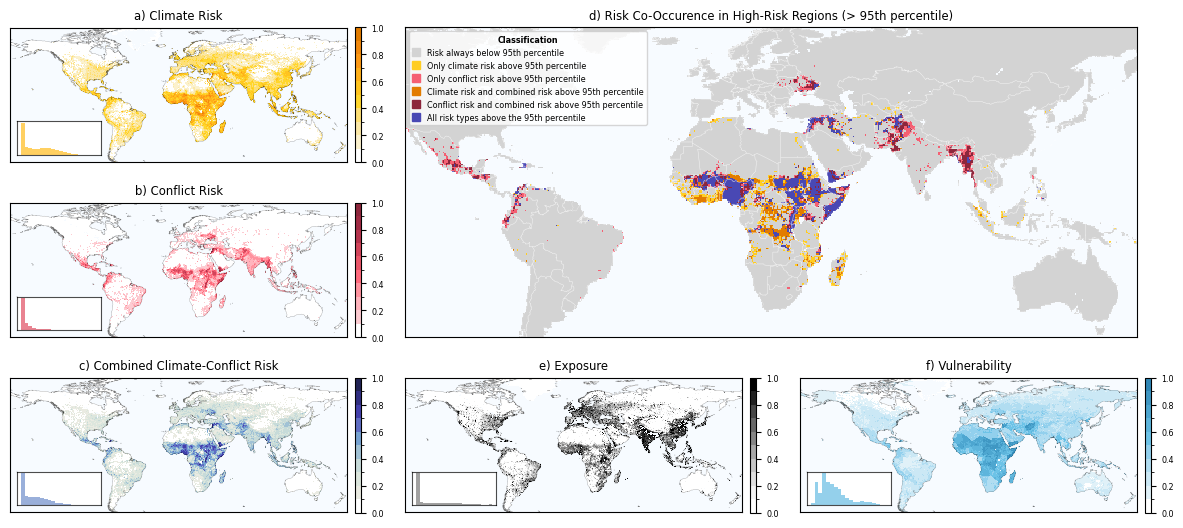

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_high_risk_overlap(df: pd.DataFrame, ax: mpl.axes.Axes, q: float=0.95, limit_view:bool=True, **kwargs):
    """Function to create ax for Figure 2d"""
    def overlap_series() -> pd.Series:
        """
        0: Risk always below {q}th percentile globally
        1: only climate risk above {q}th percentile globally
        2: only conflict risk above {q}th percentile globally
        3: climate risk and combined climate-conflict risk above {q}th percentile globally (not conflict risk)
        4: conflict risk and combined vulnerability-conflict risk above {q}th percentile globally (not climate risk)
        5: All risk types above the {q}th percentile globally
        """
        dfs = []
        scores = ["CON_risk", "CLI_risk", "CCVI"]
        for score in scores:
            mask = (df[score] > df[score].quantile(q)).astype(int)
            dfs.append(mask)
        df_dummy = pd.concat(dfs, axis = 1)
        df_dummy["CLI_overlap"] = df_dummy["CLI_risk"].astype(bool) & df_dummy["CCVI"].astype(bool) & (df_dummy[scores].sum(axis=1) != 3)
        df_dummy["CON_overlap"] = df_dummy["CON_risk"].astype(bool) & df_dummy["CCVI"].astype(bool) & (df_dummy[scores].sum(axis=1) != 3)
        df_dummy["ALL_overlap"] = df_dummy[scores].sum(axis=1) == 3
        df_dummy["NO_overlap"] = df_dummy[scores].sum(axis=1) == 0
        df_dummy["CLI_only"] = (df_dummy["CLI_risk"] - df_dummy[["CON_risk", "CCVI"]].sum(axis=1)) > 0
        df_dummy["CON_only"] = (df_dummy["CON_risk"] - df_dummy[["CLI_risk", "CCVI"]].sum(axis=1)) > 0
        df_dummy = df_dummy.drop(columns=scores)
        df_dummy["combined"] = df_dummy.apply(lambda x: 0 if x.NO_overlap else 1 if x.CLI_only else 2 if x.CON_only else 3 if x.CLI_overlap else 4 if x.CON_overlap else 5, axis=1)
        return df_dummy["combined"]

    cat_series = overlap_series()
    perc = round(q * 100)
    categories = {
        0: f"Risk always below {perc}th percentile",
        1: f"Only climate risk above {perc}th percentile",
        2: f"Only conflict risk above {perc}th percentile",
        3: f"Climate risk and combined risk above {perc}th percentile",
        4: f"Conflict risk and combined risk above {perc}th percentile",
        5: f"All risk types above the {perc}th percentile"
    }
    colors = [
        "lightgrey",
        mpl.colormaps['climate'](.5),
        mpl.colormaps['conflict'](.5),
        mpl.colormaps['climate'](1.0),
        mpl.colormaps['conflict'](1.0),
        mpl.colormaps['ccvi'](.75),
    ]

    # Colormap and normalization
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, 6, 1), cmap.N) # 5.5 included

    # Plot
    da = ccvi_series_to_xarray(cat_series)
    if limit_view:
        # select relevant view and calculate ratio, to be able to keep it consistent
        lat_pixels = float(da.lat.max() - da.lat.min() + .5)*2
        lon_pixels = float(da.lon.max() - da.lon.min() + .5)*2
        ratio = lon_pixels / lat_pixels
        ratio = ratio - .15 # we have a bit more vertical space for this map in the panel
        view = da.where(da > 0, drop=True)
        lat_max, lat_min = view.lat.max().item(), view.lat.min().item()
        lon_max, lon_min = view.lon.max().item(), view.lon.min().item()
        view_lat_pixels = (lat_max - lat_min + .5)*2
        view_lon_pixels = (lon_max - lon_min + .5)*2
        view_ratio = view_lon_pixels / view_lat_pixels
        if view_ratio > ratio: #wider - need to expand lat
            lat_expansion = (view_lon_pixels / ratio - view_lat_pixels) / 2
            ylims = (lat_min - lat_expansion/2 - .5, lat_max + lat_expansion/2 + .5)
            xlims = (lon_min -.5, lon_max + .5)
        else: #narrower - need to expand lon
            lon_expansion = (view_lat_pixels * ratio - view_lon_pixels) / 2
            ylims = (lat_min -.5, lat_max + .5)
            xlims = (lon_min - lon_expansion/2 - .5, lon_max + lon_expansion/2 + .5)
        da = da.sel(lat=slice(*ylims), lon=slice(*xlims))
    da.plot.pcolormesh(ax=ax, cmap=cmap, norm=norm, add_colorbar=False, add_labels=False, **kwargs)

    # Build a legend instead of a colorbar
    handles = [
        Patch(color=cmap(norm(i)), label=label)
        for i, label in categories.items()
    ]
    ax.legend(handles=handles, handlelength=1, handleheight=1, title="Classification", loc='upper left', fontsize="xx-small", title_fontproperties={"size":"xx-small", "weight": "bold"})
    return ax

# setup
cmaps = ["climate", "", "conflict", "ccvi", "Greys",  "vulnerability"]
scores =  ["CLI_risk", "", "CON_risk", "CCVI", "EXP_pop_density",  "VUL"]
subfigure_labels = ["a) Climate Risk", "d) Risk Co-Occurence in High-Risk Regions (> 95th percentile)", "b) Conflict Risk", "c) Combined Climate-Conflict Risk", "e) Exposure",  "f) Vulnerability" ]

# inline plot histograms
def add_histogram(ax, series, color, alpha=0.6):
    ax_inset = inset_axes(ax, width="25%", height="25%", loc="lower left")
    ax_inset.hist(series, bins=20, color=color, alpha=alpha)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    for side in ["left", "right", "top", "bottom"]:
        ax_inset.spines[side].set_alpha(alpha)

# load grid, countries and land areas to draw boundaries and the ocean
grid = GlobalBaseGrid(ConfigParser()).load(return_gdf=True)
countries = gpd.read_file(os.path.join(fp, "input/world-administrative-boundaries.geojson"))
countries = countries.loc[countries.iso3.isin(grid.iso3.unique())]
land = gpd.read_file("data/input/ne_50m_land.zip")
land = land.loc[land.clip(grid).index]
land = land.drop(index=1343)  # GRL

# Specify figure        
fig = plt.figure(figsize=(15, 6.3))
axd = fig.subplot_mosaic(
    """
    ABB
    CBB
    DEF
    """
)
bounds = np.arange(0,1.1, 0.1)

for i, id in enumerate(axd):
    axd[id].set_aspect(1, anchor="SW")
    axd[id].set_title(subfigure_labels[i], size="small")
    axd[id].set_xticks([])
    axd[id].set_yticks([])
    axd[id].set_facecolor(("aliceblue", .5))
    
    cbar_kwargs = {"label": "", "fraction": 0.075, "pad": 0.02}
    if id == "B":
        plot_high_risk_overlap(df, axd[id])
        countries.plot(ax=axd[id], facecolor="None", linewidth=0.3, edgecolor="white", alpha=0.5)
    else:
        da = ccvi_series_to_xarray(df[scores[i]]).rename(subfigure_labels[i])
        pcm = da.plot.pcolormesh(
            ax=axd[id], 
            cmap=cmaps[i], 
            vmax=1,
            vmin=0,
            add_labels=False,
            add_colorbar=False,
            levels=11
        )
        cbar = fig.colorbar(pcm, ax=axd[id], **cbar_kwargs)
        cbar.ax.tick_params(labelsize="xx-small")
        land.plot(ax=axd[id], facecolor="None", linewidth=0.2, edgecolor="black", alpha=0.5)
        add_histogram(axd[id], df[scores[i]], mpl.colormaps[cmaps[i]](0.6), .7)


fig.subplots_adjust(wspace=0.06, hspace=0.3)
plt.savefig("paper/figures/figure2-global-scores.png", dpi=600, bbox_inches="tight")
plt.show()

In [7]:
# Correlation for components visualized in Figure 2
df_fig2 = df_full[[s for s in scores if s != ""]]
df_fig2.corr()

,CLI_risk,CON_risk,CCVI,EXP_pop_density,VUL
CLI_risk,1.000000,0.732768,0.981741,0.836387,0.699180
CON_risk,0.732768,1.000000,0.843587,0.621839,0.587861
CCVI,0.981741,0.843587,1.000000,0.815539,0.687447
EXP_pop_density,0.836387,0.621839,0.815539,1.000000,0.372593
VUL,0.699180,0.587861,0.687447,0.372593,1.000000


In [8]:
from scipy.stats import pearsonr
corr = pearsonr(df_fig2.dropna()["CLI_risk"], df_fig2.dropna()["CON_risk"])
print(corr.statistic, corr.pvalue)

0.732767948111634 0.0


In [9]:
df_fig2.dropna()["CLI_risk"]

pgid    year  quarter
49901   2018  1          0.058651
              2          0.059808
              3          0.062141
              4          0.062011
        2019  1          0.057427
                           ...   
249337  2024  3          0.000608
              4          0.000625
        2025  1          0.000622
              2          0.000621
              3          0.000622
Name: CLI_risk, Length: 1783925, dtype: float64

# Figure 3: relationships between risks and risk components

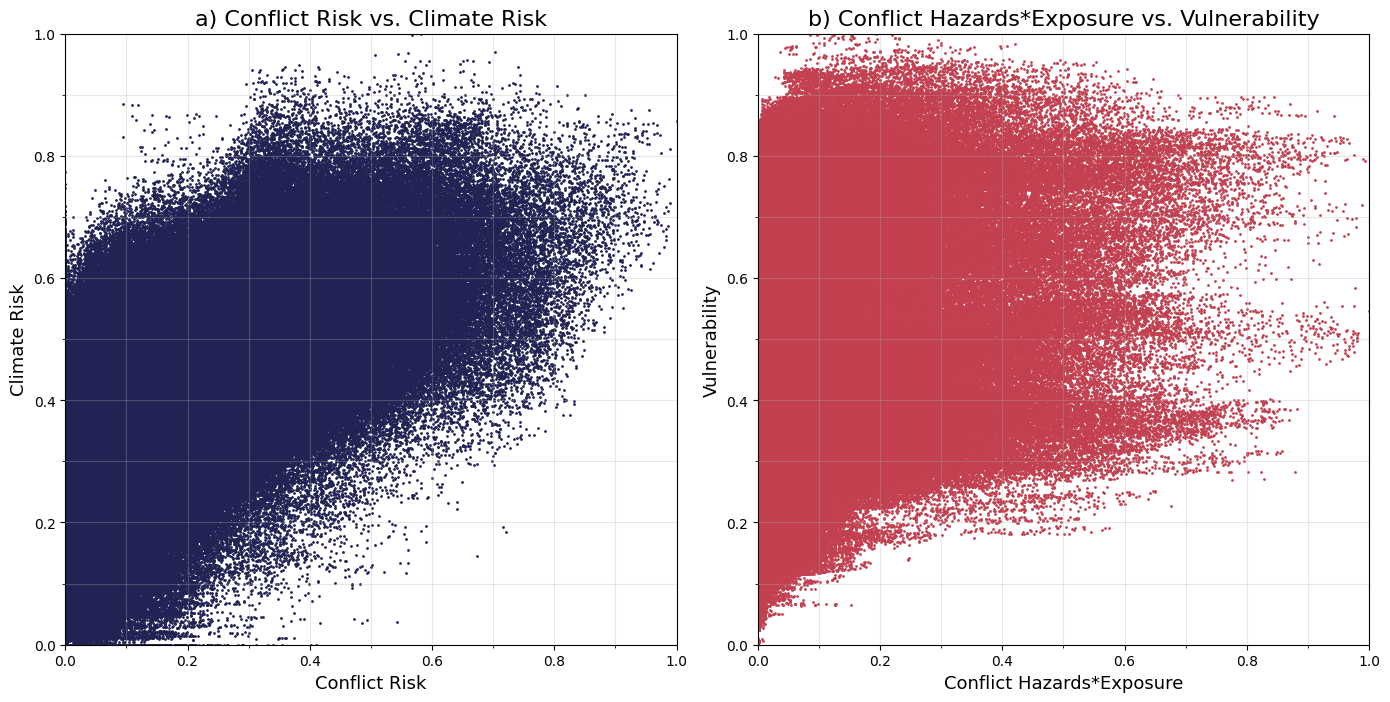

In [10]:
stitle=16
slabel=13
sticklabel=10

fig, axs = plt.subplots(1,2, figsize=(14, 7))
# conflict risk vs. climate risk
axs[0].scatter(df_full.CON_risk, df_full.CLI_risk, color=color_ccvi2, s=1)
axs[0].set_xlabel("Conflict Risk", size=slabel)
axs[0].set_ylabel("Climate Risk", size=slabel)
axs[0].set_title("a) Conflict Risk vs. Climate Risk", size=stitle)
# conflict hazard*exposure vs. climate hazard*exposure
axs[1].scatter(df_full.CON, df_full.VUL, color=color_con2, s=1)
axs[1].set_xlabel("Conflict Hazards*Exposure", size=slabel)
axs[1].set_ylabel("Vulnerability", size=slabel)
axs[1].set_title("b) Conflict Hazards*Exposure vs. Vulnerability", size=stitle)
# adjust axes
for ax in axs:
    ax.set_ylim([0, 1])
    ax.set_xlim([0, 1])
    ax.set_aspect(1)
    ax.tick_params(labelsize=sticklabel)
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("paper/figures/figure3-scatter-components", dpi=600, bbox_inches="tight")
plt.show()

## Figure SI 1: Robustness checks for Figure 2d

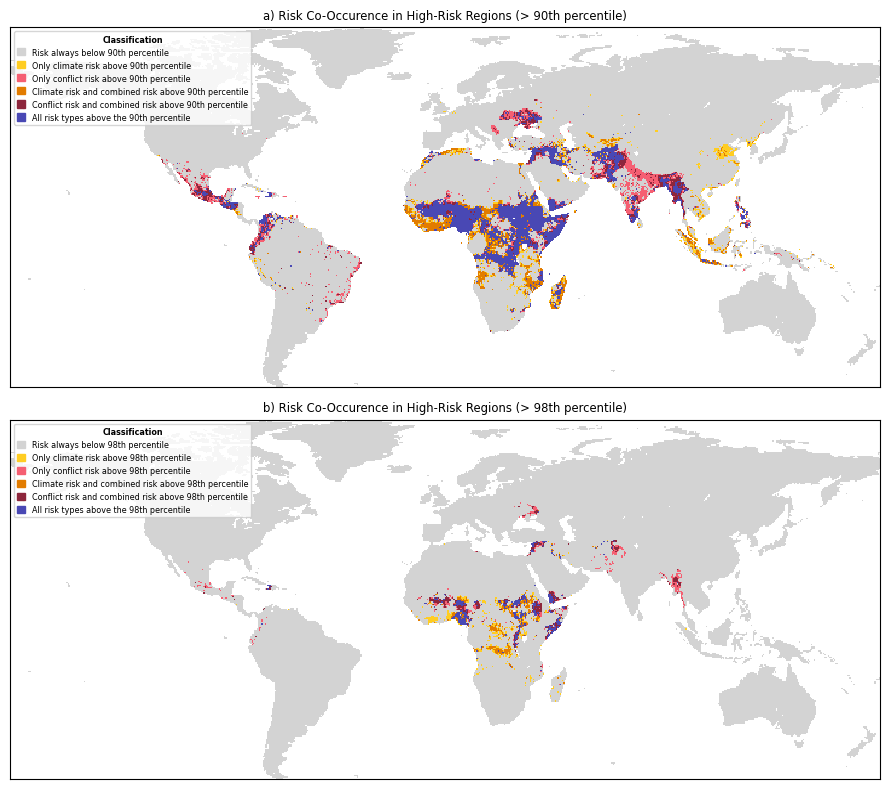

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(9,8))
plot_high_risk_overlap(df, axs[0], 0.90, limit_view=False)
axs[0].set_title("a) Risk Co-Occurence in High-Risk Regions (> 90th percentile)", size="small")
plot_high_risk_overlap(df, axs[1], 0.98, limit_view=False)
axs[1].set_title("b) Risk Co-Occurence in High-Risk Regions (> 98th percentile)", size="small")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.savefig("paper/figures/figureSI1-high-risk-overlap.png", dpi=600, bbox_inches="tight")
plt.show()

# Figure 4: Risk Profiles

### Setup

Setup Spider Plots

In [12]:
# Adjusted version of https://matplotlib.org/stable/gallery/specialty_plots/radar_chart.html
def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels, **text_kw):
            # 1) let PolarAxes compute the correct positions
            super().set_thetagrids(np.degrees(theta), labels)
            # 2) clone those tick labels as regular Text (front) and hide originals
            promoted = []
            for t in self.get_xticklabels():
                if not t.get_text():
                    continue
                new = mtext.Text(
                    0, 0, t.get_text(),
                    transform=t.get_transform(),
                    ha=t.get_ha(), va=t.get_va(),
                    rotation=t.get_rotation(),
                    rotation_mode=t.get_rotation_mode(),
                    zorder=text_kw.get('zorder', 10),
                    **{k: v for k, v in text_kw.items() if k != 'zorder'}
                )
                new.set_position(t.get_position())
                new.set_clip_on(False)
                self.add_artist(new)
                t.set_visible(False)
                promoted.append(new)
            return promoted

        def set_rgrids(self, radii, labels=None, angle=None, **text_kw):
            lines, labs = super().set_rgrids(radii, labels=labels, angle=angle)
            promoted = []
            for t in labs:
                new = mtext.Text(
                    0, 0, t.get_text(),
                    transform=t.get_transform(),
                    ha=t.get_ha(), va=t.get_va(),
                    rotation=t.get_rotation(),
                    zorder=text_kw.get('zorder', 10),
                    **{k: v for k, v in text_kw.items() if k != 'zorder'}
                )
                new.set_position(t.get_position())
                new.set_clip_on(False)
                self.add_artist(new)
                t.set_visible(False)
                promoted.append(new)
            return lines, promoted

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

Quick look at the Top50 highest CCVI values of individual grid cells to find suitable examples

In [13]:
top50 = df.sort_values('CCVI', ascending=False).iloc[:50].copy()
top50 = top50.merge(grid[["iso3"]], on="pgid", how="left")
top50

,CLI,CLI_current,CLI_accumulated,CLI_longterm,CLI_current_floods,CLI_current_cyclones,CLI_current_heavy-precipitation,CLI_current_heatwave,CLI_current_wildfires,CLI_current_drought,...,VUL_environmental_biodiversity,VUL_environmental_deforestation,VUL_environmental_soil,VUL_environmental_water,CLI_risk,CON_risk,CCVI,EXP_pop_density,EXP_pop_density_raw,iso3
pgid,,,,,,,,,,,,,,,,,,,,,
132931,0.612552,0.357991,0.540618,0.674206,0.000000,0.0,0.000000,0.317241,0.000000,0.248441,...,0.562815,9.629869e-04,0.036012,0.292795,0.857230,1.000000,1.000000,1.000000,1327.809435,SOM
130019,0.561840,0.370392,0.513498,0.558715,0.000000,0.0,0.444444,0.000000,0.000000,0.000000,...,0.625618,8.742743e-01,1.000000,0.002347,0.835518,0.906664,0.936074,0.960811,643.131518,COD
177553,0.641241,0.515690,0.437671,0.693115,0.000000,0.0,0.000000,0.151724,0.000000,0.612799,...,0.655763,2.605897e-05,0.061930,1.000000,0.827699,0.909539,0.933675,1.000000,937.576578,SYR
181875,0.610571,0.440794,0.436477,0.690455,0.000000,0.0,0.000000,0.220690,0.000000,0.461125,...,0.692713,4.305186e-05,0.088485,1.000000,0.813682,0.915691,0.930032,1.000000,989.173124,SYR
132210,0.553588,0.321163,0.530969,0.569283,0.000000,0.0,0.055556,0.227586,0.000000,0.329919,...,0.543186,8.774323e-03,0.048126,0.202879,0.814412,0.911365,0.927948,0.800394,217.770338,SOM
145899,0.560514,0.485568,0.467297,0.486332,0.000000,0.0,0.000000,0.855172,0.000000,NaN,...,0.475439,0.000000e+00,0.065454,1.000000,0.818795,0.901086,0.924378,0.874733,359.847225,SOM
127859,0.677967,0.618987,0.618701,0.503088,0.303412,0.0,0.277778,0.000000,0.899817,0.000000,...,0.350677,3.754734e-01,0.826249,0.000645,0.877168,0.837569,0.920806,0.849633,303.749188,COD
178273,0.565316,0.447483,0.324626,0.679419,0.000000,0.0,0.000000,0.055172,0.000000,0.534150,...,0.609880,3.066324e-05,0.366125,1.000000,0.782989,0.913620,0.913524,1.000000,1135.195637,SYR
180433,0.662817,0.613686,0.500584,0.587606,0.000000,0.0,0.000000,0.089655,0.499586,0.626214,...,0.722241,7.308402e-02,0.337869,1.000000,0.856195,0.841058,0.911210,0.830538,266.987927,SYR


In [14]:
top50[top50.iso3.isin(["NGA", "SSD"])]

,CLI,CLI_current,CLI_accumulated,CLI_longterm,CLI_current_floods,CLI_current_cyclones,CLI_current_heavy-precipitation,CLI_current_heatwave,CLI_current_wildfires,CLI_current_drought,...,VUL_environmental_biodiversity,VUL_environmental_deforestation,VUL_environmental_soil,VUL_environmental_water,CLI_risk,CON_risk,CCVI,EXP_pop_density,EXP_pop_density_raw,iso3
pgid,,,,,,,,,,,,,,,,,,,,,
138612,0.918383,0.796437,0.947505,0.614136,0.0,0.0,0.5,0.731034,0.0,0.550166,...,0.701204,0.674685,0.382220,0.003925,0.891092,0.678601,0.850380,0.943721,573.134281,NGA
139380,0.667085,0.452042,0.750485,0.510308,0.0,0.0,0.0,0.758621,0.0,0.544140,...,0.967770,0.007499,0.306333,0.490908,0.876830,0.677626,0.841338,0.714971,122.098048,SSD


### Figure
(unfortunately this had to be somewhat lenghty to work)

In [15]:
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, VPacker, TextArea, DrawingArea
from matplotlib.lines import Line2D

def _marker_box(marker, color, size=10, pad=0):
    da = DrawingArea(size + 2*pad, size + 2*pad, 0, 0)
    line = Line2D([size/2 + pad], [size/2 + pad],
                  marker=marker, linestyle="None",
                  markersize=size,
                  markerfacecolor=color, markeredgecolor=color,
                  color=color)
    da.add_artist(line)
    return da

def add_risk_legend_box(
    ax,
    rows,
    title="Risk Scores",
    nga_marker="<",
    ssd_marker=">",
    fontsize=10,
    title_fontsize=10,
    loc="center",
    pad=0.4,
    sep=18,          # horizontal gap between left and right columns
    rowsep=2,        # vertical gap between groups
    header_pad=2,    # vertical gap between header and the NGA/SSD row (smaller = tighter)
    title_sep=4      # vertical gap between title and first header
):
    # Title (bold)
    title_area = TextArea(
        title,
        textprops=dict(size=title_fontsize, ha="center", weight="bold")
    )

    packed_rows = []

    for r in rows:
        header = r.get("header", "")
        if header:
            # Centered subheading spanning both columns
            header_area = TextArea(header, textprops=dict(size=fontsize, ha="center"))
            packed_rows.append(header_area)
            packed_rows.append(DrawingArea(1, header_pad, 0, 0))  # smaller gap under header

        # Left column: marker then NGA text
        nga = HPacker(
            children=[
                _marker_box(nga_marker, r["nga_color"], size=fontsize),
                TextArea(" ", textprops=dict(size=fontsize)),
                TextArea(r["nga"], textprops=dict(size=fontsize))
            ],
            align="center", pad=0, sep=0
        )

        # Right column: SSD text then marker
        ssd = HPacker(
            children=[
                TextArea(r["ssd"], textprops=dict(size=fontsize)),
                TextArea(" ", textprops=dict(size=fontsize)),
                _marker_box(ssd_marker, r["ssd_color"], size=fontsize)
            ],
            align="center", pad=0, sep=0
        )

        packed_rows.append(
            HPacker(
                children=[nga, DrawingArea(sep, 1, 0, 0), ssd],
                align="center", pad=0, sep=0
            )
        )

        if r != rows[-1]:
            # smaller spacer between groups
            packed_rows.append(DrawingArea(1, rowsep, 0, 0))
        else:
            packed_rows.append(DrawingArea(1, 2, 0, 0))
            
    # Stack vertically; smaller sep tightens overall vertical spacing
    vbox = VPacker(
        children=[title_area, DrawingArea(1, title_sep, 0, 0)] + packed_rows,
        align="center",
        pad=0,
        sep=0
    )

    anchored = AnchoredOffsetbox(
        loc=loc, child=vbox, pad=pad, frameon=True, borderpad=0.6
    )
    anchored.patch.set_alpha(0.8)
    ax.add_artist(anchored)
    return anchored

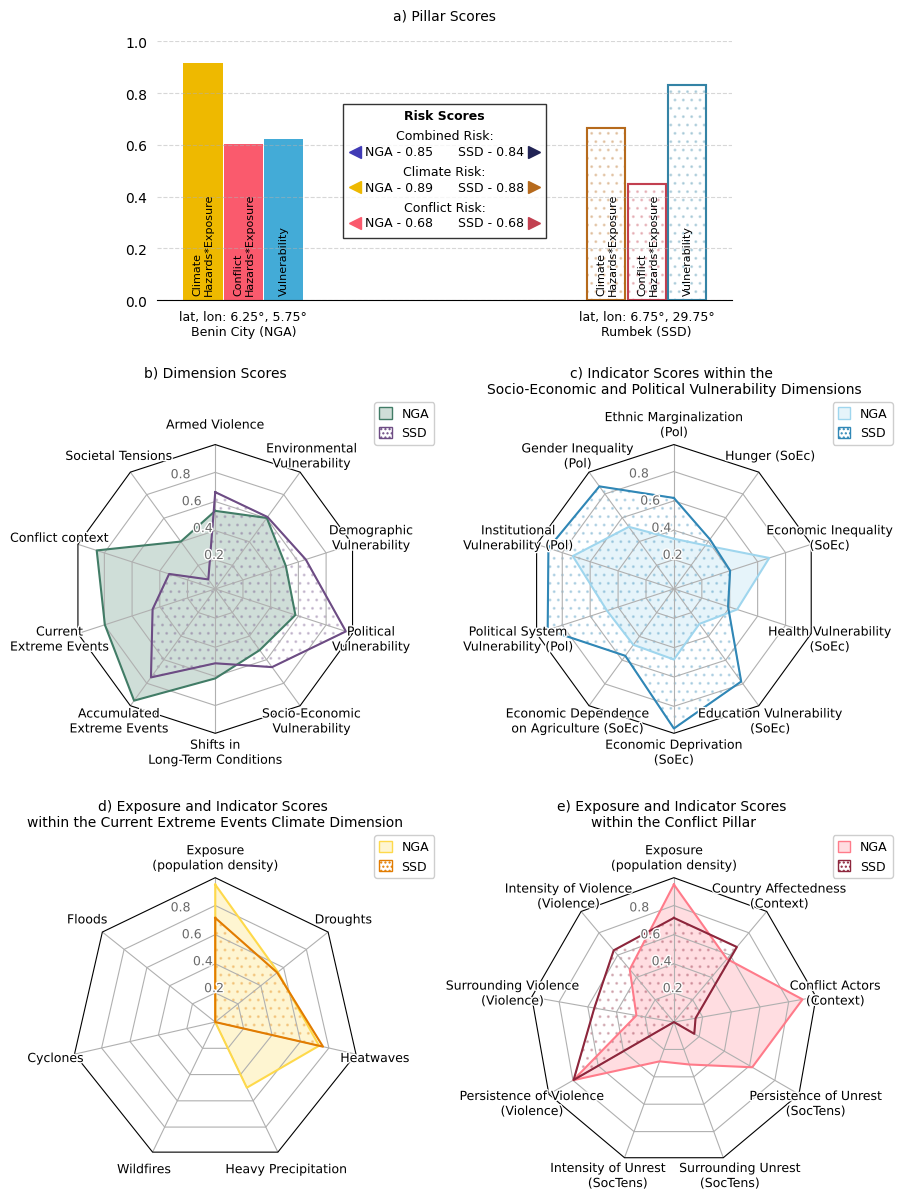

In [16]:
nga_highest = top50.loc[138612]
ssd_highest = top50.loc[139380]
locations = [
    "lat, lon: 6.25°, 5.75°\nBenin City (NGA)",
    "lat, lon: 6.75°, 29.75°\nRumbek (SSD)"
]

halo = [path_effects.withStroke(linewidth=2, foreground="white")]
label_size=9
title_size=10
legend_size=9

def radar_chart(ax, theta, indicators, labels, color_nga, color_ssd, facecolor_alpha=.25):
    # order: fills < grid < lines < labels
    ax.set_axisbelow('line')  # grid between fills and lines
    FILL_Z, LINE_Z = 0.1, 2.0

    ax.fill(theta, nga_highest[indicators], facecolor=color_nga, alpha=facecolor_alpha,
            label='_nolegend_', zorder=FILL_Z)
    ax.plot(theta, nga_highest[indicators], color=color_nga, zorder=LINE_Z)
    ax.fill(theta, ssd_highest[indicators], edgecolor=color_ssd, facecolor="None", alpha=facecolor_alpha,
            label='_nolegend_', zorder=FILL_Z, hatch="..")
    ax.plot(theta, ssd_highest[indicators], color=color_ssd, zorder=LINE_Z)

    ax.set_rgrids([0.2, 0.4, 0.6, 0.8], path_effects=halo, color="dimgrey", fontsize=label_size)
    ax.set_varlabels(labels, fontsize=label_size, path_effects=halo, zorder=10)

    facecolor_nga = list(mcolors.to_rgba(color_nga))[:3] + [facecolor_alpha]
    facecolor_ssd = list(mcolors.to_rgba(color_ssd))[:3] + [facecolor_alpha]
    handles = [
        Patch(edgecolor=color_nga, facecolor=tuple(facecolor_nga), label="NGA"),
        Patch(edgecolor=color_ssd,  facecolor="None", label="SSD", hatch="....")
    ]
    ax.legend(handles=handles, handleheight=1, handlelength=1, labelspacing=0.5,
              fontsize=label_size, loc=(1.05, 1.0), framealpha=.95)
    return ax


fig = plt.figure(figsize=(10, 15))

# bar plot - PILLARS
ax1 = fig.add_subplot(3,2,(1,2))
bars = np.arange(.5, 2, .5)
pillars = ["CLI", "CON", "VUL"]
nga = ax1.bar(bars, nga_highest[pillars], width=.49, color=[color_cli1, color_con1, color_vul1])
ax1.bar(bars+5, ssd_highest[pillars], width=.47, edgecolor=[color_cli2, color_con2, color_vul2], facecolor="None", linewidth=1.5, hatch="..", alpha=.25)
ssd = ax1.bar(bars+5, ssd_highest[pillars], width=.47, edgecolor=[color_cli2, color_con2, color_vul2], facecolor="None", linewidth=1.5,)
ax1.set_xticks([1, 6], labels=locations, size=label_size)#, rotation=45, ha="right", rotation_mode="anchor")
bar_labels = ["Climate\nHazards*Exposure", "Conflict\nHazards*Exposure", "Vulnerability"]
for i, bar in enumerate(nga):
    ax1.text(bar.get_x()+.25, bar.get_y()+.02, bar_labels[i], rotation=90, ha="center", va="bottom", ma="left", size=label_size-1)
for i, bar in enumerate(ssd):
    ax1.text(bar.get_x()+.25, bar.get_y()+.02, bar_labels[i], rotation=90, ha="center", va="bottom", ma="left", size=label_size-1)
rows = [
    dict(
        header="Combined Risk:",
        nga=f"NGA - {round(nga_highest['CCVI'], 2)}",  nga_color=color_ccvi1,
        ssd=f"SSD - {round(ssd_highest['CCVI'], 2)}",  ssd_color=color_ccvi2,
    ),
    dict(
        header="Climate Risk:",
        nga=f"NGA - {round(nga_highest['CLI_risk'], 2)}", nga_color=color_cli1,
        ssd=f"SSD - {round(ssd_highest['CLI_risk'], 2)}", ssd_color=color_cli2,
    ),
    dict(
        header="Conflict Risk:",
        nga=f"NGA - {round(nga_highest['CON_risk'], 2)}", nga_color=color_con1,
        ssd=f"SSD - {round(ssd_highest['CON_risk'], 2)}", ssd_color=color_con2,
    ),
]

add_risk_legend_box(
    ax1,
    rows,
    title="Risk Scores",
    fontsize=legend_size,
    title_fontsize=legend_size,
    loc="center",
    sep=18,
    header_pad=2,   # tighter
    rowsep=5,       # smaller group gap
    title_sep=5
)
ax1.set_ylim(0, 1)
ax1.grid(axis="y", alpha=0.5, linestyle="--")
ax1.tick_params(
    axis='both',
    which='both',
    bottom=False,
    labelbottom=True,
    left = False,
    labelleft=True)
ax1.spines[['right', 'top', 'left']].set_visible(False)
ax1.set_title("a) Pillar Scores", y=1.05, size=title_size)

# radar chart - DIMENSIONS
dimensions = [
    'CON_level',
    'CON_soctens',
    'CON_context',
    'CLI_current',
    'CLI_accumulated',
    'CLI_longterm',
    'VUL_socioeconomic',
    'VUL_political',
    'VUL_demographic',
    'VUL_environmental'
]
labels_dims = [
    'Armed Violence',
    'Societal Tensions',
    'Conflict context',
    'Current\nExtreme Events',
    'Accumulated\nExtreme Events',
    'Shifts in\nLong-Term Conditions',
    'Socio-Economic\nVulnerability',
    'Political\nVulnerability',
    'Demographic\nVulnerability',
    'Environmental\nVulnerability'
]
theta = radar_factory(len(dimensions), frame='polygon')
ax2 = fig.add_subplot(323, projection = "radar")
ax2 = radar_chart(
    ax = ax2,
    theta=theta,
    indicators = dimensions,
    labels = labels_dims,
    color_nga = "#417C66",
    color_ssd = "#6D4C84"
)
ax2.set_title("b) Dimension Scores\n", size=title_size, y=1.15)

# radar chart - VULNERABILITY
vulnerability_indicators = [
    'VUL_political_ethnic',
    'VUL_political_gender',
    'VUL_political_institutions',
    'VUL_political_system',
    'VUL_socioeconomic_agriculture',
    'VUL_socioeconomic_deprivation',
    'VUL_socioeconomic_education',
    'VUL_socioeconomic_health',
    'VUL_socioeconomic_inequality',
    'VUL_socioeconomic_hunger',
]
vulnerability_labels = [
    'Ethnic Marginalization\n(Pol)',
    'Gender Inequality\n(Pol)',
    'Institutional\nVulnerability (Pol)',
    'Political System\nVulnerability (Pol)',
    'Economic Dependence\non Agriculture (SoEc)',
    'Economic Deprivation\n(SoEc)',
    'Education Vulnerability\n(SoEc)',
    'Health Vulnerability\n(SoEc)',
    'Economic Inequality\n(SoEc)',
    'Hunger (SoEc)',
]
theta = radar_factory(len(vulnerability_indicators), frame='polygon')
ax3 = fig.add_subplot(324, projection = "radar")
ax3 = radar_chart(
    ax = ax3,
    theta=theta,
    indicators = vulnerability_indicators,
    labels = vulnerability_labels,
    color_nga = mpl.colormaps["vulnerability"]([.4]),
    color_ssd = mpl.colormaps["vulnerability"]([1.0])
)
ax3.set_title("c) Indicator Scores within the \nSocio-Economic and Political Vulnerability Dimensions", size=title_size, y=1.15)

# radar chart - CLIMATE
climate_indicators = [
    'EXP_pop_density',
    'CLI_current_floods',
    'CLI_current_cyclones',
    'CLI_current_wildfires',
    'CLI_current_heavy-precipitation',
    'CLI_current_heatwave',
    'CLI_current_drought',
]
climate_labels = [
    'Exposure\n(population density)',
    'Floods',
    'Cyclones',
    'Wildfires',
    'Heavy Precipitation',
    'Heatwaves',
    'Droughts',
]
theta = radar_factory(len(climate_indicators), frame='polygon')
ax4 = fig.add_subplot(325, projection = "radar")
ax4 = radar_chart(
    ax = ax4,
    theta=theta,
    indicators = climate_indicators,
    labels = climate_labels,
    color_nga = mpl.colormaps["climate"]([.4]),
    color_ssd = mpl.colormaps["climate"]([1.0])
)
ax4.set_title("d) Exposure and Indicator Scores \nwithin the Current Extreme Events Climate Dimension", size=title_size, y=1.15)

# radar chart - CONFLICT
conflict_indicators = [
    'EXP_pop_density',
    'CON_level_intensity',
    'CON_level_surrounding',
    'CON_level_persistence',
    'CON_soctens_intensity',
    'CON_soctens_surrounding',
    'CON_soctens_persistence',
    'CON_context_actors',
    'CON_context_country'
]
conflict_labels = [
    'Exposure\n(population density)',
    'Intensity of Violence\n(Violence)',
    'Surrounding Violence\n(Violence)',
    'Persistence of Violence\n(Violence)',
    'Intensity of Unrest     \n(SocTens)',
    '     Surrounding Unrest\n(SocTens)',
    'Persistence of Unrest\n(SocTens)',
    'Conflict Actors\n(Context)',
    'Country Affectedness\n(Context)'
]
theta = radar_factory(len(conflict_indicators), frame='polygon')
ax5 = fig.add_subplot(326, projection = "radar")
ax5 = radar_chart(
    ax = ax5,
    theta=theta,
    indicators = conflict_indicators,
    labels = conflict_labels,
    color_nga = mpl.colormaps["conflict"]([.4]),
    color_ssd = mpl.colormaps["conflict"]([1.0])
)
ax5.set_title("e) Exposure and Indicator Scores \nwithin the Conflict Pillar", size=title_size, y=1.15)

plt.subplots_adjust(hspace=0.5, wspace=0.45)
pos = ax1.get_position()
ax1.set_position((pos.x0 +.1, pos.y0, pos.width-.2, pos.height-.02))
plt.savefig("paper/figures/figure4-risk-profiles.png", dpi=600, bbox_inches="tight")
plt.show()